# EEEM068 – Applied Machine Learning | Group 42
## Part B – Base Face Diffusion Model (Pathway 2: Pretrained)

**Model:** Stable Diffusion v1-5 (`runwayml/stable-diffusion-v1-5`)  
**Paper:** Rombach et al., *High-Resolution Image Synthesis with Latent Diffusion Models*, CVPR 2022  
**Paper link:** https://arxiv.org/abs/2112.10752  
**Built for:** torch 2.10.0 · diffusers 0.37.1 · transformers 5.0.0 (Colab pre-installed)

## Cell 0 — Install Only Missing Packages
**No version changes — only installs what Colab doesn't already have.**

In [1]:
# Force reinstall torch with the correct CUDA version for Kaggle's GPU
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

In [2]:
# Only install packages not pre-installed on Colab
# Do NOT upgrade diffusers/transformers/torch — use what's already there
!pip install -q pytorch-fid
!pip install -q datasets

print("Done. No restart needed — continue to Cell 1.")

Done. No restart needed — continue to Cell 1.


## Cell 1 — Verify Environment

In [3]:
import torch
import diffusers
import transformers

print(f"torch        : {torch.__version__}")
print(f"diffusers    : {diffusers.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU")

torch        : 2.10.0+cu128
diffusers    : 0.36.0
transformers : 5.0.0
CUDA         : True
GPU          : Tesla T4
VRAM         : 15.6 GB


## Cell 2 — Imports & Configuration

In [4]:
import os, json, re, subprocess
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

# ── Fixed sampling protocol (shared across Parts B, C, D) ────────────────────
SAMPLING_CONFIG = {
    "num_inference_steps" : 25,
    "guidance_scale"      : 7.5,
    "height"              : 256,
    "width"               : 256,
    "seed"                : SEED,
}

# ── Fixed prompt set (10 prompts — used for ALL identities/methods) ───────────
PROMPT_SET = [
    "a high quality portrait photo of a person, neutral expression, front facing, soft lighting",
    "a high quality portrait photo of a person, slight smile, front facing, studio lighting",
    "a high quality portrait photo of a person, neutral expression, slight left turn, natural lighting",
    "a high quality portrait photo of a person, neutral expression, slight right turn, natural lighting",
    "a high quality portrait photo of a person, happy expression, front facing, warm lighting",
    "a high quality portrait photo of a person, serious expression, front facing, cool lighting",
    "a high quality portrait photo of a person, neutral expression, outdoor background, daylight",
    "a high quality portrait photo of a person, neutral expression, indoor background, soft lighting",
    "a high quality portrait photo of a person, looking upward slightly, diffused lighting",
    "a high quality portrait photo of a person, looking downward slightly, diffused lighting",
]

# ── Output paths ──────────────────────────────────────────────────────────────
OUTPUT_DIR       = Path("outputs/partB")
GENERATED_DIR    = OUTPUT_DIR / "generated_images"
REAL_DIR         = OUTPUT_DIR / "real_test_images"
SAMPLE_GRIDS_DIR = OUTPUT_DIR / "sample_grids"
for d in [GENERATED_DIR, REAL_DIR, SAMPLE_GRIDS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Generation settings ───────────────────────────────────────────────────────
N_GENERATE  = 300
N_REAL      = 300
BATCH_SIZE  = 4      # reduce to 2 or 1 if you get CUDA out-of-memory
REAL_OFFSET = 29700  # last 300 of 30k CelebA-HQ = consistent test split

print("Configuration loaded.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
Configuration loaded.


## Cell 3 — Load Pretrained Stable Diffusion v1-5

In [5]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
print(f"Loading {MODEL_ID} ...")

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
    use_safetensors=True,
)

# DPM-Solver++ — fast high-quality sampling at 25 steps
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()  # saves VRAM on T4

print("Model loaded.")
print(f"Scheduler  : {pipe.scheduler.__class__.__name__}")
print(f"UNet params: {sum(p.numel() for p in pipe.unet.parameters()) / 1e6:.1f}M")

Loading runwayml/stable-diffusion-v1-5 ...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Scheduler  : DPMSolverMultistepScheduler
UNet params: 859.5M


## Cell 4 — Prepare Real Test Images (CelebA-HQ 256×256)

Loading CelebA faces from HuggingFace ...


dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

Saving 300 real test images ...
  50/300 ...
  100/300 ...
  150/300 ...
  200/300 ...
  250/300 ...
  300/300 ...
Saved 300 real images.


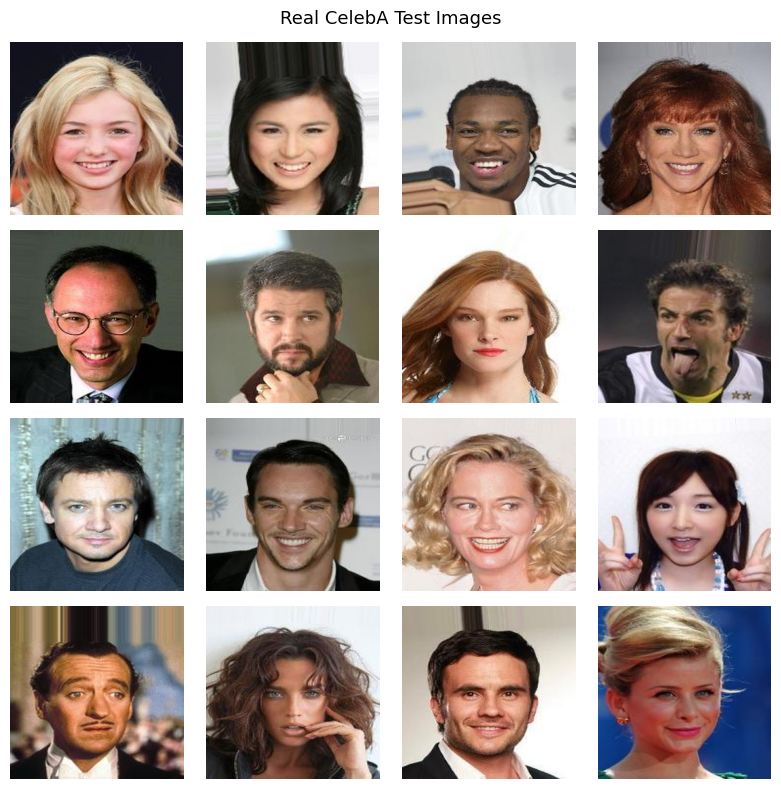

In [6]:
from datasets import load_dataset
from PIL import Image

print("Loading CelebA faces from HuggingFace ...")
ds = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)

saved = 0
print(f"Saving {N_REAL} real test images ...")
for i, sample in enumerate(ds):
    if i < REAL_OFFSET:
        continue
    try:
        img = sample["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = img.resize((256, 256), Image.LANCZOS)
        img.save(REAL_DIR / f"real_{saved:04d}.png")
        saved += 1
        if saved % 50 == 0:
            print(f"  {saved}/{N_REAL} ...")
        if saved >= N_REAL:
            break
    except Exception as e:
        print(f"  Skipping sample {i}: {e}")
        continue

print(f"Saved {saved} real images.")

# Sample grid
real_paths = sorted(REAL_DIR.glob("*.png"))[:16]
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, p in zip(axes.flatten(), real_paths):
    ax.imshow(Image.open(p))
    ax.axis("off")
plt.suptitle("Real CelebA Test Images", fontsize=13)
plt.tight_layout()
plt.savefig(SAMPLE_GRIDS_DIR / "real_test_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 5 — Generate 300 Face Images

In [7]:
images_per_prompt = N_GENERATE // len(PROMPT_SET)  # 30 per prompt
img_idx = 0

print(f"Generating {N_GENERATE} images ({images_per_prompt} per prompt) ...")
print(f"Steps: {SAMPLING_CONFIG['num_inference_steps']} | CFG: {SAMPLING_CONFIG['guidance_scale']} | Batch: {BATCH_SIZE}\n")

for prompt_idx, prompt in enumerate(PROMPT_SET):
    n_batches        = (images_per_prompt + BATCH_SIZE - 1) // BATCH_SIZE
    done_this_prompt = 0

    for batch_idx in tqdm(range(n_batches), desc=f"Prompt {prompt_idx+1:02d}/{len(PROMPT_SET)}"):
        batch_seed = SEED + prompt_idx * 1000 + batch_idx
        generator  = torch.Generator(device=DEVICE).manual_seed(batch_seed)
        cur_batch  = min(BATCH_SIZE, images_per_prompt - done_this_prompt)

        # torch.amp.autocast is the correct API for torch >= 2.0
        with torch.amp.autocast(device_type="cuda"):
            result = pipe(
                prompt              = [prompt] * cur_batch,
                height              = SAMPLING_CONFIG["height"],
                width               = SAMPLING_CONFIG["width"],
                num_inference_steps = SAMPLING_CONFIG["num_inference_steps"],
                guidance_scale      = SAMPLING_CONFIG["guidance_scale"],
                generator           = generator,
            )

        for img in result.images:
            img.save(GENERATED_DIR / f"gen_{img_idx:04d}_p{prompt_idx:02d}.png")
            img_idx += 1
            done_this_prompt += 1

print(f"\nDone. {img_idx} images saved to {GENERATED_DIR}")

Generating 300 images (30 per prompt) ...
Steps: 25 | CFG: 7.5 | Batch: 4



Prompt 01/10:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]


Done. 300 images saved to outputs/partB/generated_images


## Cell 6 — Sample Grids (Qualitative)

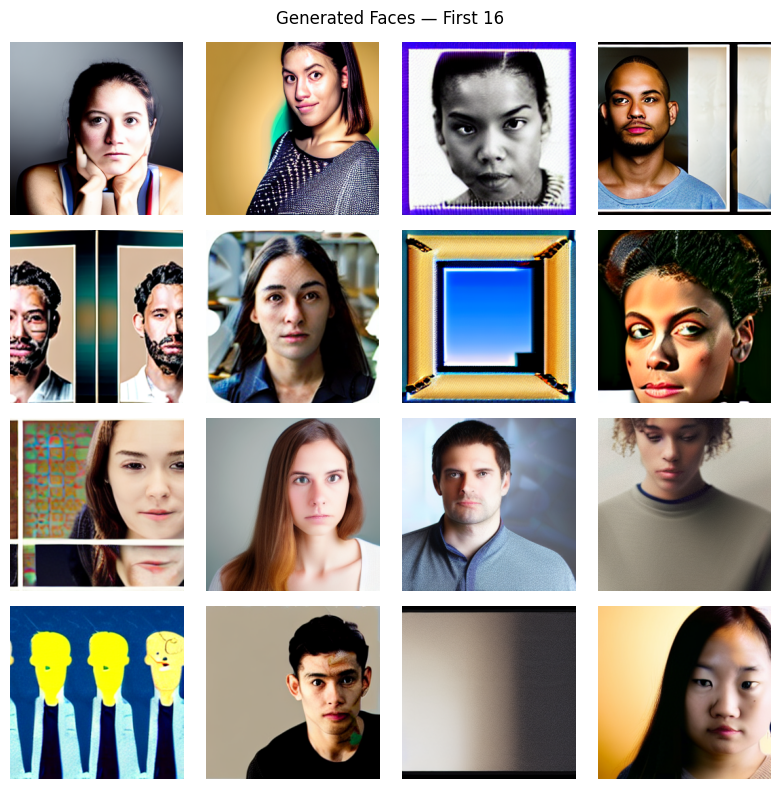

Saved: outputs/partB/sample_grids/grid_first16.png


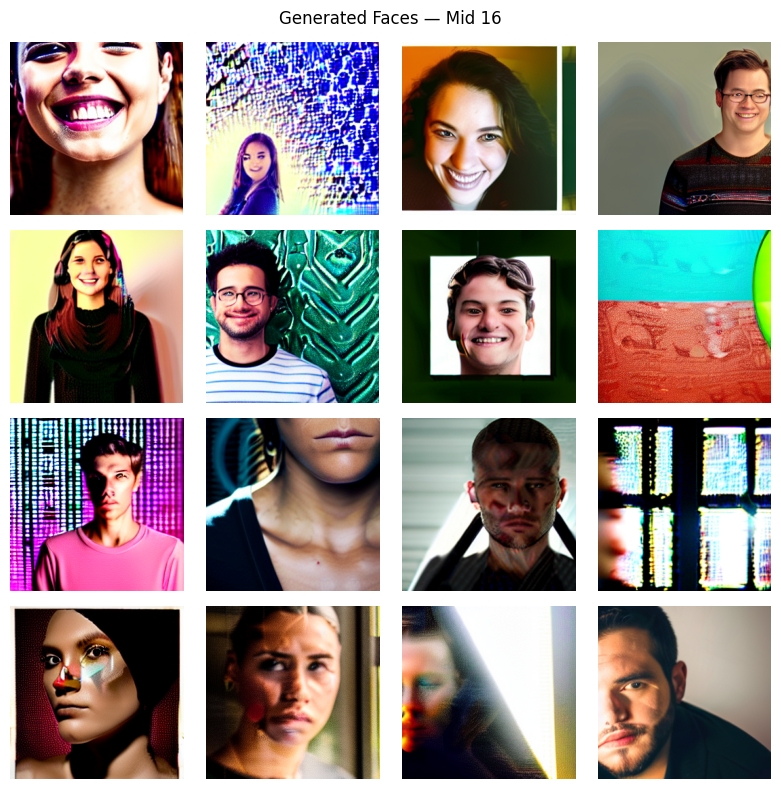

Saved: outputs/partB/sample_grids/grid_mid16.png


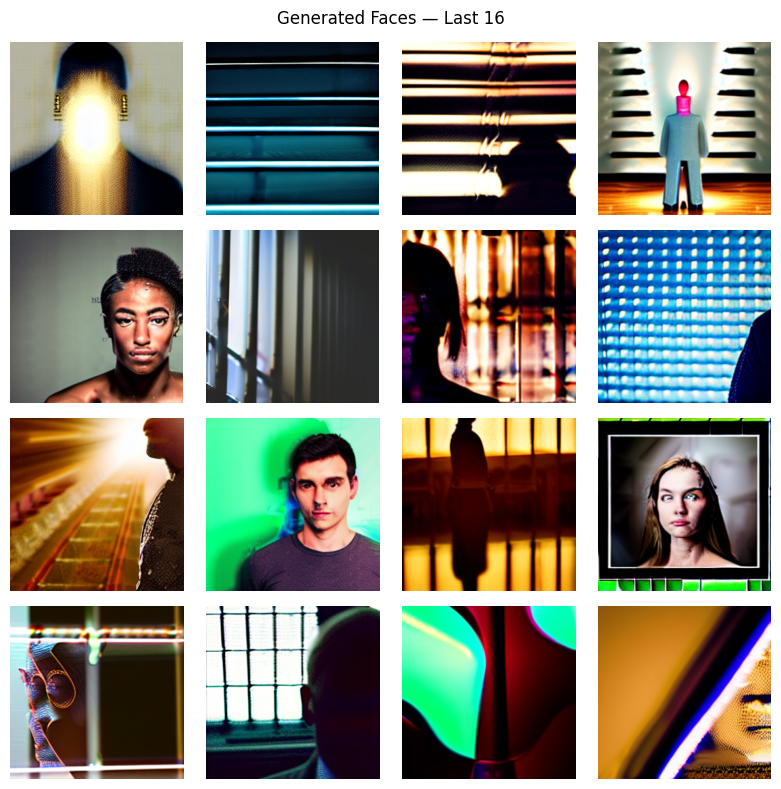

Saved: outputs/partB/sample_grids/grid_last16.png


In [8]:
def save_image_grid(image_paths, title, save_path, nrow=4, ncol=4):
    fig, axes = plt.subplots(ncol, nrow, figsize=(nrow * 2, ncol * 2))
    for ax, p in zip(axes.flatten(), image_paths[:nrow * ncol]):
        ax.imshow(Image.open(p))
        ax.axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

gen_paths = sorted(GENERATED_DIR.glob("*.png"))
save_image_grid(gen_paths[:16],     "Generated Faces — First 16", SAMPLE_GRIDS_DIR / "grid_first16.png")
save_image_grid(gen_paths[142:158], "Generated Faces — Mid 16",   SAMPLE_GRIDS_DIR / "grid_mid16.png")
save_image_grid(gen_paths[-16:],    "Generated Faces — Last 16",  SAMPLE_GRIDS_DIR / "grid_last16.png")

## Cell 7 — Compute Baseline FID
**Reference:** Heusel et al., *GANs Trained by a Two Time-Scale Update Rule*, NeurIPS 2017.

In [9]:
print(f"Real      : {len(list(REAL_DIR.glob('*.png')))} images")
print(f"Generated : {len(list(GENERATED_DIR.glob('*.png')))} images")
print("Computing FID ...\n")

result = subprocess.run(
    ["python", "-m", "pytorch_fid",
     str(REAL_DIR), str(GENERATED_DIR),
     "--device", DEVICE, "--batch-size", "16"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

match = re.search(r"FID:\s*([\d\.]+)", result.stdout)
fid_score = float(match.group(1)) if match else None

print("="*40)
print(f"  Baseline FID: {fid_score:.2f}" if fid_score else "  FID not parsed — check output above")
print("="*40)

Real      : 300 images
Generated : 300 images
Computing FID ...

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
FID:  184.28980894295827

  Baseline FID: 184.29


## Cell 8 — Save Config & Results Summary

In [10]:
config = {
    "model_id"        : MODEL_ID,
    "paper"           : "Rombach et al., CVPR 2022",
    "paper_url"       : "https://arxiv.org/abs/2112.10752",
    "torch_version"   : torch.__version__,
    "diffusers_version": diffusers.__version__,
    "sampling_config" : SAMPLING_CONFIG,
    "prompt_set"      : PROMPT_SET,
    "n_generated"     : N_GENERATE,
    "n_real_test"     : N_REAL,
    "real_offset"     : REAL_OFFSET,
    "dataset"         : "kornia/CelebA-HQ (HuggingFace)",
    "baseline_fid"    : fid_score,
}
with open(OUTPUT_DIR / "partB_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("="*50)
print("  PART B — RESULTS SUMMARY")
print("="*50)
print(f"  Model         : {MODEL_ID}")
print(f"  Scheduler     : DPM-Solver++ ({SAMPLING_CONFIG['num_inference_steps']} steps)")
print(f"  CFG scale     : {SAMPLING_CONFIG['guidance_scale']}")
print(f"  Resolution    : {SAMPLING_CONFIG['height']}x{SAMPLING_CONFIG['width']}")
print(f"  Prompts       : {len(PROMPT_SET)} (fixed set)")
print(f"  Generated     : {len(list(GENERATED_DIR.glob('*.png')))} images")
print(f"  Real test set : {len(list(REAL_DIR.glob('*.png')))} images")
if fid_score:
    print(f"  Baseline FID  : {fid_score:.2f}")
print("="*50)
print(f"Config saved → {OUTPUT_DIR}/partB_config.json")

  PART B — RESULTS SUMMARY
  Model         : runwayml/stable-diffusion-v1-5
  Scheduler     : DPM-Solver++ (25 steps)
  CFG scale     : 7.5
  Resolution    : 256x256
  Prompts       : 10 (fixed set)
  Generated     : 300 images
  Real test set : 300 images
  Baseline FID  : 184.29
Config saved → outputs/partB/partB_config.json


In [11]:
# Kaggle version — outputs are automatically available in the output panel
import shutil
shutil.make_archive("/kaggle/working/partB_outputs", "zip", "outputs/partB")
print("Done — find partB_outputs.zip in the output panel on the right")

Done — find partB_outputs.zip in the output panel on the right
